# Breast Thermography 3D Reconstruction (DMR-IR) - Orthographic Geometric Pipeline

**Scope:** Pure geometric 2.5D reconstruction from five segmented thermal views (0 deg, +/-45 deg, +/-90 deg).  
**Goal:** Reconstruct a smooth 3D NURBS-like breast surface and extract asymmetry descriptors for downstream NNMF-ReliefF and Ensemble CNN analysis.  
**Framework:** NumPy + PyTorch + SciPy (edge-computing friendly).

---

## Protocol lock (Moura VISAPP 2024/2025 aligned)

1. Input is a 1-pixel skeletonized contour from semantic segmentation (256x256).
2. Phase 3 uses anatomical anchors (P1, P2, P3) with strict lateral clipping.
3. Phase 4 rotates around anatomical pivots (never camera center).
4. Phase 4 follows Algorithm 1 rigid registration: move local P2 to origin, rotate, then translate to frontal P1 or P3 target anchor.
5. Phase 5 surface interpolation uses B-spline fitting with degree 4 (`kx=4`, `ky=4`) and evaluation step `0.01` in parametric space.
6. Phase 6 outputs numeric geometry features, not only rendered figures.

This notebook includes reference functions that follow these constraints directly.

---

## Phase 1 - Data Loading and Normalization

This phase pairs each thermal TIFF with its binary mask, resizes both to $256 \times 256$, and converts them to tensors suitable for U-Net input.

The thermal image is min-max normalized to preserve temperature contrast while mapping values into a stable learning range:

$$
m_{ij} = \frac{P_{ij} - \min(P)}{\max(P) - \min(P)}
$$

This is equivalent to the paper's normalized intensity step before model training.

In [1]:
%pip install torch torchvision tifffile opencv-python scikit-learn matplotlib pandas seaborn tensorflow keras cv2


/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install opencv-python

/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


### 1.1 ThermalDataset class

The dataset class performs three important jobs:

1. Finds mask files recursively and uses them as the reference sample list.
2. Locates each TIFF robustly using filename-prefix matching to avoid Unicode mismatches (for example degree-symbol variants).
3. Returns image-mask pairs as shape $(1, H, W)$ tensors so they are immediately compatible with the U-Net input/output format.

This design is intentionally defensive for Windows path and encoding edge cases.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split
import tifffile as tiff
import cv2
import numpy as np
import os
import glob

# ── FIX 2: Reproducibility seed ──────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


class ThermalDataset(Dataset):
    def __init__(self, tiff_dir, mask_dir):
        # We find all masks first as they represent our ground truth batch
        self.mask_paths = glob.glob(os.path.join(mask_dir, "**", "*.png"), recursive=True)
        self.tiff_dir = tiff_dir
        self.mask_dir = mask_dir
        print(f"Dataset initialized with {len(self.mask_paths)} masks.")

    def __len__(self):
        return len(self.mask_paths)

    def __getitem__(self, idx):
        mask_path = self.mask_paths[idx]

        # 1. Get the patient folder and filename (e.g., Patient_106/benign/Right Lateral...)
        rel_path = os.path.relpath(mask_path, self.mask_dir)
        patient_subfolder = os.path.dirname(rel_path)
        mask_filename = os.path.basename(rel_path)

        # 2. Robust TIFF Search: Find the TIFF that matches the mask name
        # We search the folder directly to avoid encoding mismatches with the degree symbol
        tiff_search_folder = os.path.join(self.tiff_dir, patient_subfolder)
        base_name = os.path.splitext(mask_filename)[0]

        # We use a wildcard search to find the .tiff file matching the start of the mask name
        # This bypasses the specific encoding of the (90°) part
        search_pattern = os.path.join(tiff_search_folder, "*.tiff")
        potential_tiffs = glob.glob(search_pattern)

        tiff_path = None
        for p_tiff in potential_tiffs:
            if base_name[:10] in os.path.basename(p_tiff):  # Match first 10 chars (e.g., 'Right Late')
                tiff_path = p_tiff
                break

        if tiff_path is None or not os.path.exists(tiff_path):
            raise FileNotFoundError(f"Could not find matching TIFF for {mask_path}")

        # 3. Load and Normalize TIFF (Paper Eq 1) [cite: 113]
        raw_data = tiff.imread(tiff_path)
        t_min, t_max = np.min(raw_data), np.max(raw_data)

        # Prevent division by zero
        if t_max == t_min:
            normalized = np.zeros_like(raw_data, dtype=np.float32)
        else:
            normalized = (raw_data - t_min) / (t_max - t_min)

        img_256 = cv2.resize(normalized.astype(np.float32), (256, 256), interpolation=cv2.INTER_AREA)

        # 4. Load Mask
        # Use np.fromfile to bypass Windows encoding issues with the degree symbol (°)
        img_array = np.fromfile(mask_path, dtype=np.uint8)
        mask = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Could not read mask file (might be corrupted or empty): {mask_path}")
        mask_256 = cv2.resize(mask, (256, 256)).astype(np.float32) / 255.0

        # Return as (C, H, W) tensors
        return torch.from_numpy(img_256).unsqueeze(0), torch.from_numpy(mask_256).unsqueeze(0)


# Paths in Thinkpad environment (adjust as needed)
TIFF_BASE = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient"
MASK_BASE = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/GroundTruth_Masks"

# ── FIX 1: Train / test split — 78 % / 22 % per paper §3.3 ──────────────────
full_dataset = ThermalDataset(TIFF_BASE, MASK_BASE)
n_total = len(full_dataset)
n_train = int(0.78 * n_total)
n_test  = n_total - n_train
train_set, test_set = random_split(
    full_dataset, [n_train, n_test],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"Split: {n_train} train / {n_test} test  (total={n_total})")

train_loader = DataLoader(train_set, batch_size=2, shuffle=True)   # Batch size 2 as per paper
test_loader  = DataLoader(test_set,  batch_size=2, shuffle=False)


Dataset initialized with 162 masks.
Split: 126 train / 36 test  (total=162)


### 1.2 Training-time augmentation

To reduce overfitting on a limited medical dataset, augmentation is applied only to training batches.

- Horizontal flip is applied to both image and mask so spatial correspondence remains correct.
- Brightness jitter is applied only to the thermal image.

This keeps anatomical geometry valid while improving generalization.

In [4]:
import albumentations as A
import torch
import torchvision.transforms.functional as TF

# ── FIX 3: Advanced Data Augmentation (Albumentations) ────────────────────────
# This targets the >0.95 Dice goal using High-Intensity augmentation
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
    A.GridDistortion(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.2), # Cutout
])

def augment(img_tensor, mask_tensor):
    """Applies Albumentations to the PyTorch tensors."""
    # Convert tensors (1, H, W) to numpy (H, W) for albumentations
    img_np = img_tensor.squeeze().numpy()
    mask_np = mask_tensor.squeeze().numpy()
    
    augmented = train_transform(image=img_np, mask=mask_np)
    
    img_aug = torch.from_numpy(augmented['image']).unsqueeze(0)
    mask_aug = torch.from_numpy(augmented['mask']).unsqueeze(0)
    return img_aug, mask_aug

/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_3285759/72320324.py:10: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
/tmp/ipykernel_3285759/72320324.py:13: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.2), # Cutout


---

## Phase 2 - U-Net Architecture (Stronger V2)

The model is now a **4-level encoder-decoder U-Net** with skip connections, BatchNorm, dropout regularization, and He initialization for better convergence stability.

Each block uses:

$\text{Conv}(3\times3) \rightarrow \text{BN} \rightarrow \text{ReLU} \rightarrow \text{Conv}(3\times3) \rightarrow \text{BN} \rightarrow \text{ReLU}$

### Channel flow

| Stage | Channels |
|---|---|
| Encoder 1 | 1 -> 64 |
| Encoder 2 | 64 -> 128 |
| Encoder 3 | 128 -> 256 |
| Encoder 4 | 256 -> 512 |
| Bottleneck | 512 -> 1024 |
| Decoder 4 | 1024 -> 512 |
| Decoder 3 | 512 -> 256 |
| Decoder 2 | 256 -> 128 |
| Decoder 1 | 128 -> 64 |
| Output | 64 -> 1 (logits) |

The output layer returns **logits** (no sigmoid in the model head). Sigmoid is applied only when computing Dice/visualization/inference thresholding.

In [5]:
import torch.nn as nn

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=64, dropout=0.2):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        self.enc1 = DoubleConv(in_channels, base_channels, dropout=0.0)
        self.enc2 = DoubleConv(base_channels, base_channels * 2, dropout=0.0)
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4, dropout=0.1)
        self.enc4 = DoubleConv(base_channels * 4, base_channels * 8, dropout=0.1)

        self.bottleneck = DoubleConv(base_channels * 8, base_channels * 16, dropout=dropout)

        self.up4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.att4 = AttentionBlock(F_g=base_channels * 8, F_l=base_channels * 8, F_int=base_channels * 4)
        self.dec4 = DoubleConv(base_channels * 16, base_channels * 8, dropout=0.1)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.att3 = AttentionBlock(F_g=base_channels * 4, F_l=base_channels * 4, F_int=base_channels * 2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4, dropout=0.1)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.att2 = AttentionBlock(F_g=base_channels * 2, F_l=base_channels * 2, F_int=base_channels)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2, dropout=0.0)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.att1 = AttentionBlock(F_g=base_channels, F_l=base_channels, F_int=base_channels // 2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels, dropout=0.0)

        self.out = nn.Conv2d(base_channels, out_channels, kernel_size=1)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.constant_(module.weight, 1)
            nn.init.constant_(module.bias, 0)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        u4 = self.up4(b)
        x4 = self.att4(g=u4, x=e4)
        d4 = self.dec4(torch.cat([u4, x4], dim=1))

        u3 = self.up3(d4)
        x3 = self.att3(g=u3, x=e3)
        d3 = self.dec3(torch.cat([u3, x3], dim=1))

        u2 = self.up2(d3)
        x2 = self.att2(g=u2, x=e2)
        d2 = self.dec2(torch.cat([u2, x2], dim=1))

        u1 = self.up1(d2)
        x1 = self.att1(g=u1, x=e1)
        d1 = self.dec1(torch.cat([u1, x1], dim=1))
        
        return self.out(d1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Attention U-Net ready on: {device} | trainable params: {num_params:,}")

Attention U-Net ready on: cuda | trainable params: 31,388,013


### 2.1 Dice coefficient metric

Binary cross-entropy is used for optimization, but Dice is the key overlap metric for segmentation quality.

Dice is computed as:

$$
\text{Dice} = \frac{2|A \cap B| + \epsilon}{|A| + |B| + \epsilon}
$$

where $A$ is the thresholded prediction and $B$ is the ground-truth mask.

In [6]:
# ── Dice coefficient that supports logits ─────────────────────────────────────
def dice_coeff(pred, target, threshold=0.5, eps=1e-6, from_logits=True):
    """Dice over batch. pred/target shape: (B,1,H,W)."""
    if from_logits:
        pred = torch.sigmoid(pred)
    pred_bin = (pred > threshold).float()

    intersection = (pred_bin * target).sum(dim=(1, 2, 3))
    denominator = pred_bin.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + eps) / (denominator + eps)
    return dice.mean()

---

### 2.2 Training loop (AdamW + BCEWithLogits+Dice + early stopping)

| Hyperparameter | Value |
|---|---|
| Loss | $0.6\times\text{BCEWithLogits} + 0.4\times\text{DiceLoss}$ |
| Optimizer | AdamW |
| Learning rate | $3 \times 10^{-4}$ (adaptive via ReduceLROnPlateau) |
| Weight decay | $1 \times 10^{-4}$ |
| Batch size | 2 |
| Max epochs | 120 |
| Early stopping patience | 12 epochs without val-Dice improvement |
| Stability tricks | AMP (CUDA), gradient clipping (1.0) |

The loop logs train loss, train Dice, validation Dice, and learning rate.  
Best validation-Dice weights are saved immediately to preserve the strongest checkpoint.

In [7]:
%pip install tqdm ipywidgets


/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
from tqdm.notebook import tqdm  # Progress bar for Jupyter / VS Code

In [12]:
from sklearn.model_selection import KFold
import torch.nn.functional as F
import copy
import numpy as np

# --- Focal-Dice Loss Definition ---
class FocalDiceLoss(nn.Module):
    def __init__(self, focal_weight=0.5, dice_weight=0.5, gamma=2.0, alpha=0.25):
        super().__init__()
        self.focal_w = focal_weight
        self.dice_w = dice_weight
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        # 1. Focal Loss
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        focal_loss = focal_loss.mean()

        # 2. Dice Loss
        probs = torch.sigmoid(logits)
        num = 2 * (probs * targets).sum(dim=(1,2,3))
        den = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3)) + 1e-6
        dice_loss = 1 - (num / den).mean()

        return self.focal_w * focal_loss + self.dice_w * dice_loss, focal_loss, dice_loss

# --- K-Fold Settings ---
k_folds = 5
num_epochs = 120
patience = 12
use_amp = device.type == "cuda"

kfold = KFold(n_splits=k_folds, shuffle=True, random_state=SEED)
fold_results = []

for fold, (train_ids, val_ids) in enumerate(kfold.split(full_dataset)):
    print(f"\n========== FOLD {fold+1}/{k_folds} ==========")
    
    # Slice the dataset for this fold
    train_sub = torch.utils.data.Subset(full_dataset, train_ids)
    val_sub = torch.utils.data.Subset(full_dataset, val_ids)
    
    train_loader = DataLoader(train_sub, batch_size=2, shuffle=True)
    val_loader = DataLoader(val_sub, batch_size=2, shuffle=False)
    
    # Initialize a FRESH model, optimizer, and scaler for each fold
    model = UNet().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6)
    
    # NEW CRITERION: Focal-Dice Loss
    criterion = FocalDiceLoss(focal_weight=0.5, dice_weight=0.5)
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    
    best_dice = 0.0
    epochs_no_imp = 0
    best_ckpt = f"unet_fold_{fold+1}.pth"
    
    for epoch in range(num_epochs):
        model.train()
        epoch_dice = 0.0
        
        # --- Training Loop ---
        for imgs, masks in train_loader:
            imgs, masks = augment(imgs, masks)
            imgs, masks = imgs.to(device), masks.to(device)
            
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(imgs)
                loss, _, _ = criterion(logits, masks)
                
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            
            epoch_dice += dice_coeff(logits.detach(), masks, from_logits=True).item()
            
        # --- Validation Loop ---
        model.eval()
        val_dice = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                logits = model(imgs)
                val_dice += dice_coeff(logits, masks, from_logits=True).item()
                
        val_dice /= len(val_loader)
        scheduler.step(val_dice)
        
        # --- Checkpoint Saving ---
        if val_dice > best_dice:
            best_dice = val_dice
            epochs_no_imp = 0
            torch.save(model.state_dict(), best_ckpt)
        else:
            epochs_no_imp += 1
            if epochs_no_imp >= patience:
                print(f"Early stopping fold {fold+1} at epoch {epoch+1}.")
                break
                
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:03d} | Train Dice: {epoch_dice/len(train_loader):.4f} | Val Dice: {val_dice:.4f}")
            
    print(f"Fold {fold+1} Best Val Dice: {best_dice:.4f} -> Saved to {best_ckpt}")
    fold_results.append(best_dice)

# --- Final Metrics for the Thesis ---
print("\n========== FINAL K-FOLD RESULTS ==========")
for i, res in enumerate(fold_results):
    print(f"Fold {i+1}: {res:.4f}")
print(f"Average Val Dice: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}")


========== FOLD 1/5 ==========
Epoch 010 | Train Dice: 0.8276 | Val Dice: 0.8120
Epoch 020 | Train Dice: 0.8813 | Val Dice: 0.8041
Epoch 030 | Train Dice: 0.8782 | Val Dice: 0.8643
Epoch 040 | Train Dice: 0.9077 | Val Dice: 0.8770
Epoch 050 | Train Dice: 0.9167 | Val Dice: 0.8814
Epoch 060 | Train Dice: 0.9316 | Val Dice: 0.8822
Epoch 070 | Train Dice: 0.9212 | Val Dice: 0.8865
Epoch 080 | Train Dice: 0.9302 | Val Dice: 0.8853
Epoch 090 | Train Dice: 0.9277 | Val Dice: 0.8853
Epoch 100 | Train Dice: 0.9327 | Val Dice: 0.8857
Early stopping fold 1 at epoch 101.
Fold 1 Best Val Dice: 0.8872 -> Saved to unet_fold_1.pth

========== FOLD 2/5 ==========
Epoch 010 | Train Dice: 0.7974 | Val Dice: 0.7620
Epoch 020 | Train Dice: 0.8727 | Val Dice: 0.8951
Epoch 030 | Train Dice: 0.8892 | Val Dice: 0.9125
Epoch 040 | Train Dice: 0.8960 | Val Dice: 0.9155
Early stopping fold 2 at epoch 46.
Fold 2 Best Val Dice: 0.9170 -> Saved to unet_fold_2.pth

========== FOLD 3/5 ==========
Epoch 010 | Train D

In [13]:
import os
import glob
import cv2
import numpy as np
import tifffile as tiff
import torch
from tqdm.notebook import tqdm

# --- Configuration ---
DATA_DIR = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient"
OUTPUT_UNET_DIR = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient_unet"
os.makedirs(OUTPUT_UNET_DIR, exist_ok=True)

def load_thermal_for_unet(path):
    raw = tiff.imread(path).astype(np.float32)
    mn, mx = raw.min(), raw.max()
    normalized = np.zeros_like(raw) if mx - mn < 1e-6 else (raw - mn) / (mx - mn)
    img_256 = cv2.resize(normalized, (256, 256), interpolation=cv2.INTER_AREA)
    return torch.from_numpy(img_256).unsqueeze(0).unsqueeze(0)

def refine_unet_mask(mask_prob, threshold=0.5):
    binary = (mask_prob > threshold).astype(np.uint8)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros_like(binary)
    largest_contour = max(contours, key=cv2.contourArea)
    refined_mask = np.zeros_like(binary)
    cv2.drawContours(refined_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
    return refined_mask

def generate_ensemble_unet_masks():
    print("Loading all 5 K-Fold models for ensembling...")
    models = []
    for i in range(1, 6):
        m = UNet().to(device)
        m.load_state_dict(torch.load(f"unet_fold_{i}.pth", map_location=device))
        m.eval()
        models.append(m)
        
    patient_folders = [f for f in os.listdir(DATA_DIR) if f.startswith('Patient_')]
    print(f"Found {len(patient_folders)} patients. Starting Ensembled U-Net extraction...")
    
    processed_count = 0
    with torch.no_grad():
        for patient in tqdm(patient_folders, desc="Processing Ensemble Masks"):
            patient_path = os.path.join(DATA_DIR, patient)
            subdirs = [d for d in os.listdir(patient_path) if os.path.isdir(os.path.join(patient_path, d))]
            category_name = subdirs[0] if subdirs else ""
            input_subfolder = os.path.join(patient_path, category_name)
            
            out_subfolder = os.path.join(OUTPUT_UNET_DIR, patient, category_name)
            os.makedirs(out_subfolder, exist_ok=True)
            
            for tiff_path in glob.glob(os.path.join(input_subfolder, "*.tiff")):
                view_name = os.path.basename(tiff_path).replace('.tiff', '')
                tensor = load_thermal_for_unet(tiff_path).to(device)
                
                # --- ENSEMBLE AVERAGING ---
                ensemble_probs = np.zeros((256, 256), dtype=np.float32)
                for m in models:
                    logits = m(tensor)
                    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
                    ensemble_probs += probs
                ensemble_probs /= 5.0  # Average the 5 models
                
                # Refine, resize, and save safely
                refined_mask_256 = refine_unet_mask(ensemble_probs, threshold=0.5)
                final_mask_128 = cv2.resize(refined_mask_256, (128, 128), interpolation=cv2.INTER_NEAREST)
                
                out_file = os.path.join(out_subfolder, f"{view_name}_unet_mask.png")
                _, buf = cv2.imencode('.png', final_mask_128)
                buf.tofile(out_file)
                processed_count += 1

    print(f"Done! Generated {processed_count} ensembled U-Net masks.")

# Run the ensembler
generate_ensemble_unet_masks()


Loading all 5 K-Fold models for ensembling...
Found 137 patients. Starting Ensembled U-Net extraction...


Processing Ensemble Masks:   0%|          | 0/137 [00:00<?, ?it/s]

Done! Generated 657 ensembled U-Net masks.


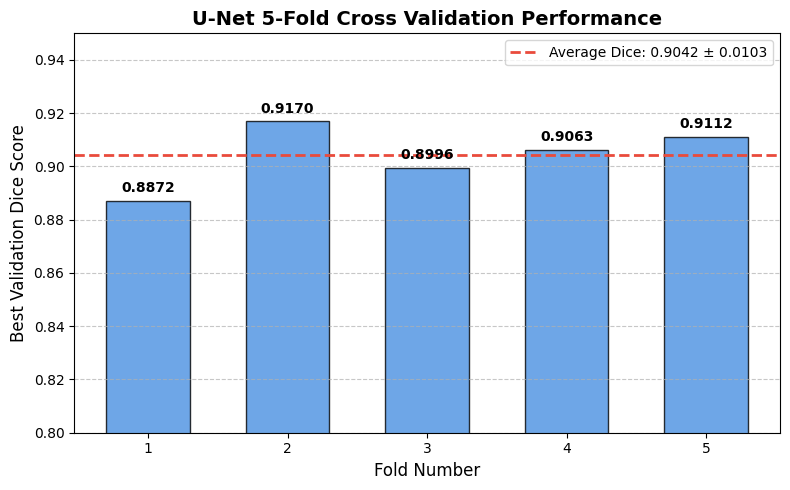

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 'fold_results' is already in memory from the previous cell!
folds = np.arange(1, 6)
scores = fold_results
avg_score = np.mean(scores)
std_dev = np.std(scores)

fig, ax = plt.subplots(figsize=(8, 5))

# Plot the bars
bars = ax.bar(folds, scores, color='#4A90E2', edgecolor='black', alpha=0.8, width=0.6)

# Add a dashed red line for the average
ax.axhline(avg_score, color='#E94B3C', linestyle='--', linewidth=2, 
           label=f'Average Dice: {avg_score:.4f} ± {std_dev:.4f}')

# Zoom the Y-axis to make differences visible (e.g., from 0.80 to 0.95)
ax.set_ylim(0.80, 0.95)

# Labels and Title
ax.set_title('U-Net 5-Fold Cross Validation Performance', fontsize=14, fontweight='bold')
ax.set_xlabel('Fold Number', fontsize=12)
ax.set_ylabel('Best Validation Dice Score', fontsize=12)
ax.set_xticks(folds)

# Add the exact numbers on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot for your thesis!
plt.savefig("kfold_results_chart.png", dpi=300, bbox_inches='tight')
plt.show()


Visualizing Ensembled U-Net Masks for Patient_216...


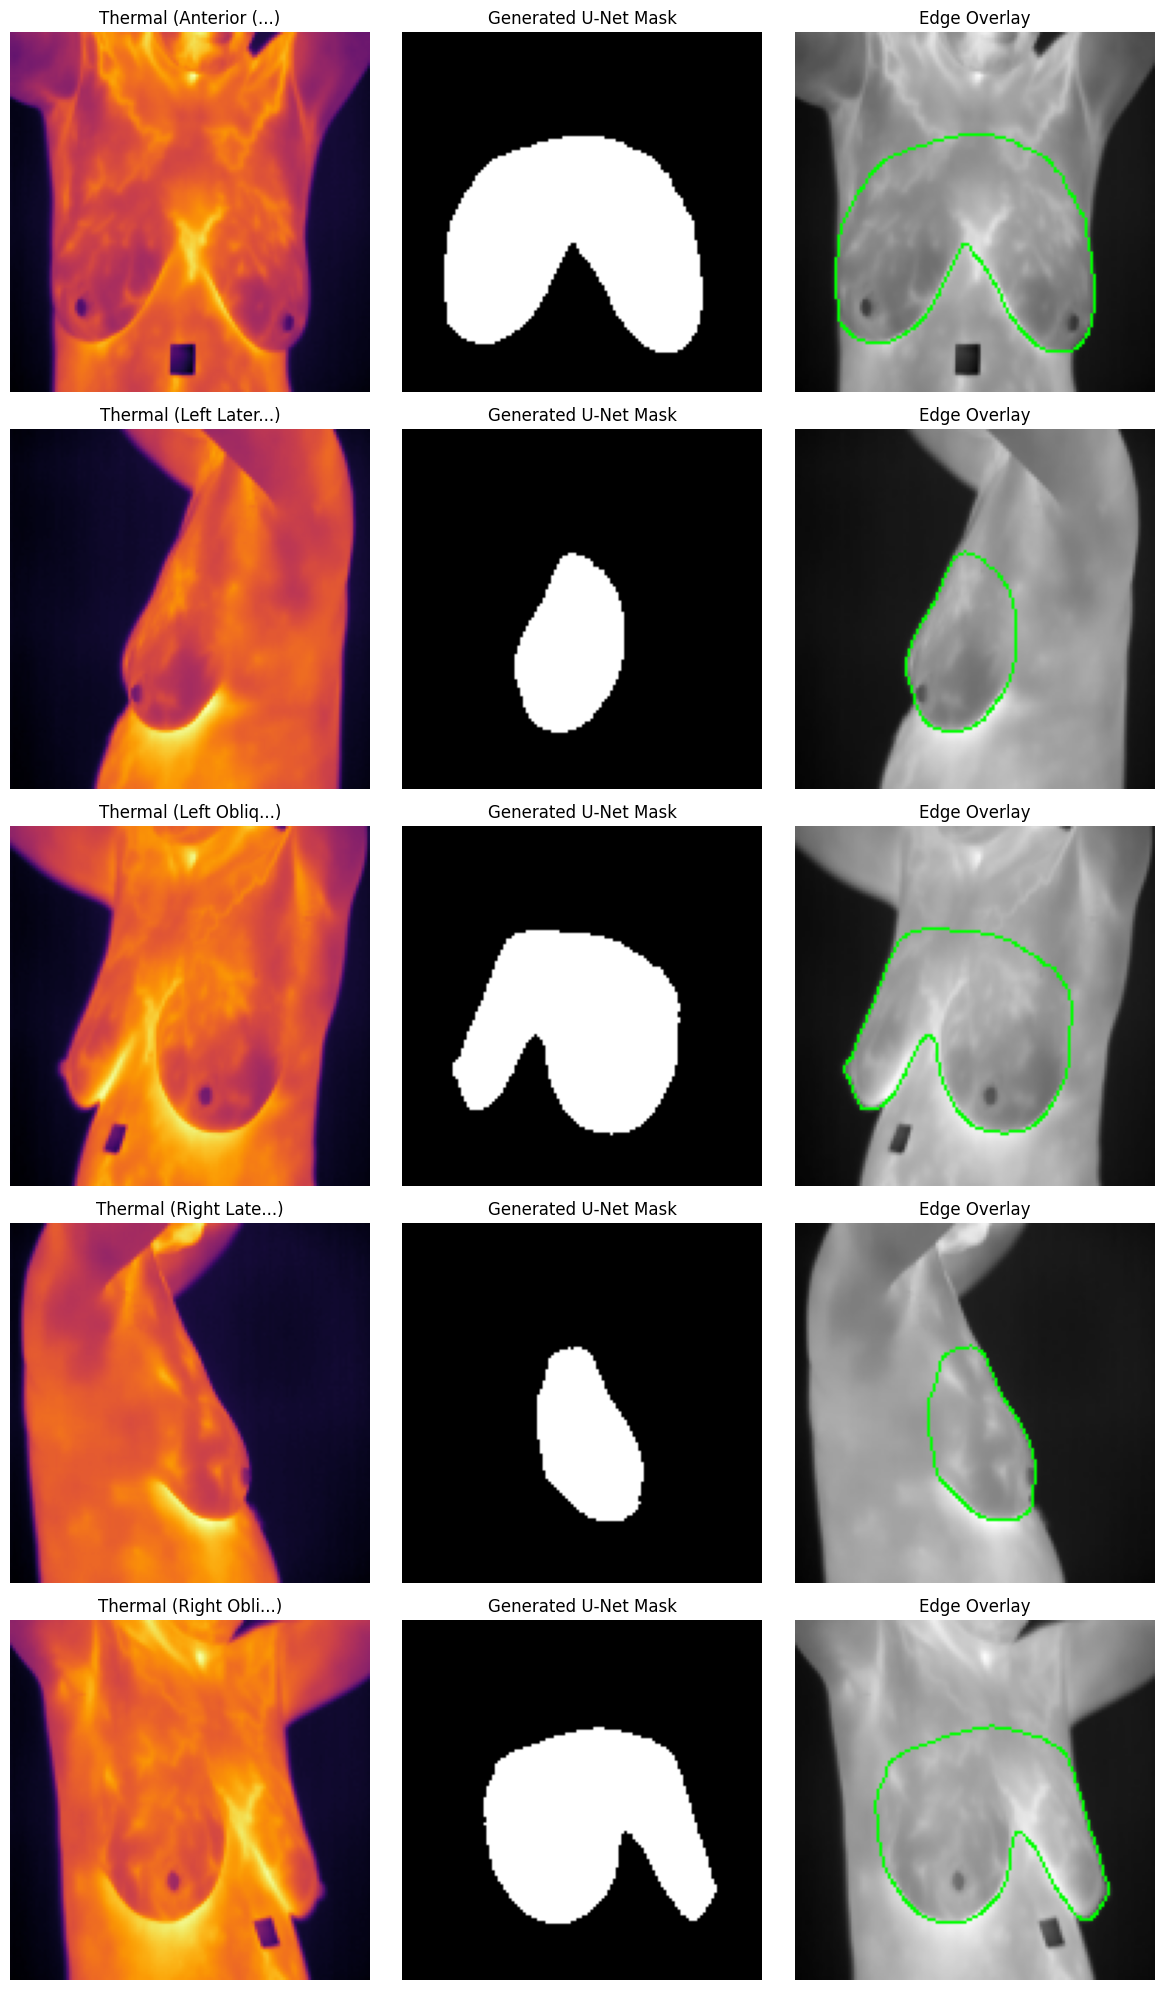

In [28]:
import random
import matplotlib.pyplot as plt

def display_random_unet_masks():
    patient_folders = [f for f in os.listdir(OUTPUT_UNET_DIR) if f.startswith('Patient_')]
    if not patient_folders:
        print("No processed patients found! Run the extraction first.")
        return
        
    patient = random.choice(patient_folders)
    print(f"Visualizing Ensembled U-Net Masks for {patient}...")
    
    out_patient_dir = os.path.join(OUTPUT_UNET_DIR, patient)
    subdirs = [d for d in os.listdir(out_patient_dir) if os.path.isdir(os.path.join(out_patient_dir, d))]
    category = subdirs[0] if subdirs else ""
    
    out_subfolder = os.path.join(out_patient_dir, category)
    in_subfolder = os.path.join(DATA_DIR, patient, category)
    
    mask_files = sorted(glob.glob(os.path.join(out_subfolder, "*.png")))
    if not mask_files:
        return
        
    fig, axes = plt.subplots(len(mask_files), 3, figsize=(12, 4 * len(mask_files)))
    if len(mask_files) == 1: axes = axes[np.newaxis, :]
        
    for i, mask_path in enumerate(mask_files):
        view_name = os.path.basename(mask_path).replace('_unet_mask.png', '')
        
        # Load mask safely (Windows bug fix)
        mask_bytes = np.fromfile(mask_path, dtype=np.uint8)
        mask = cv2.imdecode(mask_bytes, cv2.IMREAD_GRAYSCALE)
        if mask is None: continue
            
        search_prefix = view_name[:10]
        matching_tiffs = [f for f in glob.glob(os.path.join(in_subfolder, "*.tiff")) if search_prefix in os.path.basename(f)]
        if not matching_tiffs: continue
            
        # Load original
        img_normalized = load_thermal_for_unet(matching_tiffs[0]).squeeze().cpu().numpy()
        img_128 = cv2.resize(img_normalized, (128, 128), interpolation=cv2.INTER_AREA)
        
        # Overlay
        overlay = cv2.cvtColor((img_128 * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
        edges = cv2.Canny(mask, 50, 150)
        
        # Safely assign green color
        if edges is not None and np.any(edges > 0):
            overlay[edges > 0] = [0, 255, 0]
            
        # Plot
        axes[i, 0].imshow(img_128, cmap='inferno')
        axes[i, 0].set_title(f"Thermal ({search_prefix}...)")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title("Generated U-Net Mask")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Edge Overlay")
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

display_random_unet_masks()
